<a href="https://colab.research.google.com/github/jayshivankar/Logistic-Regression/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# data set - https://drive.google.com/file/d/1YptNOOqUIcZqyC_xOxb1tmzjco7d3cqS/view?usp=drive_link

In [ ]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

# ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# data import
data = pd.read_csv('/content/drive/MyDrive/Datasets/Input/diabetes.csv')

# data sample
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# data dimensions
data.shape

(768, 9)

In [ ]:
# missing values
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# data type
data.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
# duplicates
data[data.duplicated].shape[0]

0

In [ ]:
# analyse the target columns
round(data['Outcome'].value_counts(normalize=True)*100, 2)

,proportion
Outcome,
0,65.1
1,34.9


In [ ]:
from re import X
# preparing the data for ML model

# dependency split
x = data.drop(['Outcome'], axis=1)
y = data['Outcome']

# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# data scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# logistic regression model
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(x_train_scaled, y_train)
print('Training Accuracy:', round(logreg_model.score(x_train_scaled, y_train)*100, 2), '%')

Training Accuracy: 77.04 %


Testing Accuracy: 75.32 %
Classification Report:

               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



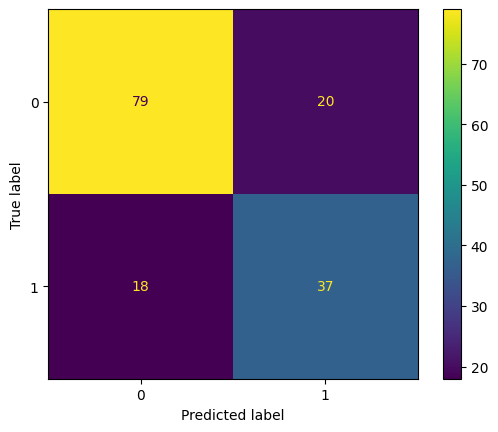

In [ ]:
# Model testing
y_pred = logreg_model.predict(x_test_scaled)

# metrics
print('Testing Accuracy:', round(accuracy_score(y_test, y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

In [ ]:
# importing oversampler
from imblearn.over_sampling import SMOTE

In [ ]:
# resample
smote = SMOTE(random_state=42)

# do sampling only for the learning data
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

In [ ]:
# data distribution after SMOTE
round(y_train_smote.value_counts(normalize=True)*100, 2)

,proportion
Outcome,
0,50.0
1,50.0


In [ ]:
# logistic regression model
logreg_model_sm = LogisticRegression(random_state=42)
logreg_model_sm.fit(x_train_smote, y_train_smote)
print('Training Accuracy:', round(logreg_model_sm.score(x_train_smote, y_train_smote)*100, 2), '%')

Training Accuracy: 75.94 %


Testing Accuracy: 70.78 %
Classification Report:

               precision    recall  f1-score   support

           0       0.82      0.70      0.75        99
           1       0.57      0.73      0.64        55

    accuracy                           0.71       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154



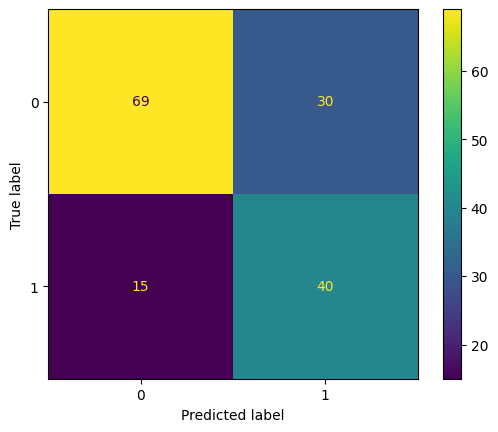

In [ ]:
# Model testing
y_pred_sm = logreg_model_sm.predict(x_test_scaled)

# metrics
print('Testing Accuracy:', round(accuracy_score(y_test, y_pred_sm)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sm)
print('Classification Report:\n\n', classification_report(y_test, y_pred_sm))